In [1]:
"""
SMS Phishing Dataset - Exploratory Data Analysis
Day 2: Understanding our data before preprocessing
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

from src.config import SMS_RAW_DATA, REPORTS_DIR

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports successful")
print(f"Data location: {SMS_RAW_DATA}")

✓ Configuration loaded successfully
Project Root: c:\Users\MY PC\phishing_detection_system
Data Directory: c:\Users\MY PC\phishing_detection_system\data
✓ Imports successful
Data location: c:\Users\MY PC\phishing_detection_system\data\raw\sms_data.csv


In [2]:
# Load dataset
df = pd.read_csv(SMS_RAW_DATA)

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
print(df.isnull().sum())

DATASET OVERVIEW

Shape: (5572, 2)
Columns: ['label', 'message']

First few rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Data types:
label      object
message    object
dtype: object

Missing values:
label      0
message    0
dtype: int64



CLASS DISTRIBUTION
label
ham     4825
spam     747
Name: count, dtype: int64

Percentages:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


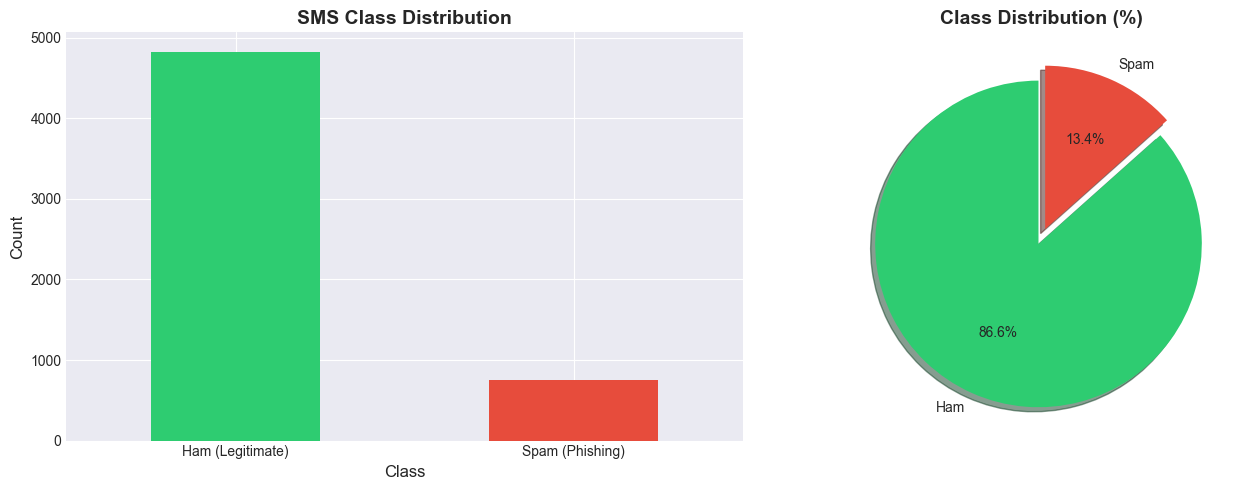


✓ Visualization saved to reports/class_distribution.png


In [3]:
# Class distribution
print("\n" + "="*60)
print("CLASS DISTRIBUTION")
print("="*60)

label_counts = df['label'].value_counts()
print(label_counts)
print(f"\nPercentages:")
print(df['label'].value_counts(normalize=True) * 100)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
label_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('SMS Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Ham (Legitimate)', 'Spam (Phishing)'], rotation=0)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)
axes[1].pie(label_counts.values, labels=['Ham', 'Spam'], autopct='%1.1f%%',
            colors=colors, explode=explode, shadow=True, startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to reports/class_distribution.png")


MESSAGE LENGTH STATISTICS

By Character Count:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0

By Word Count:
        count       mean        std  min   25%   50%   75%    max
label                                                            
ham    4825.0  14.310259  11.517945  1.0   7.0  11.0  19.0  171.0
spam    747.0  23.911647   5.780174  2.0  22.0  25.0  28.0   35.0


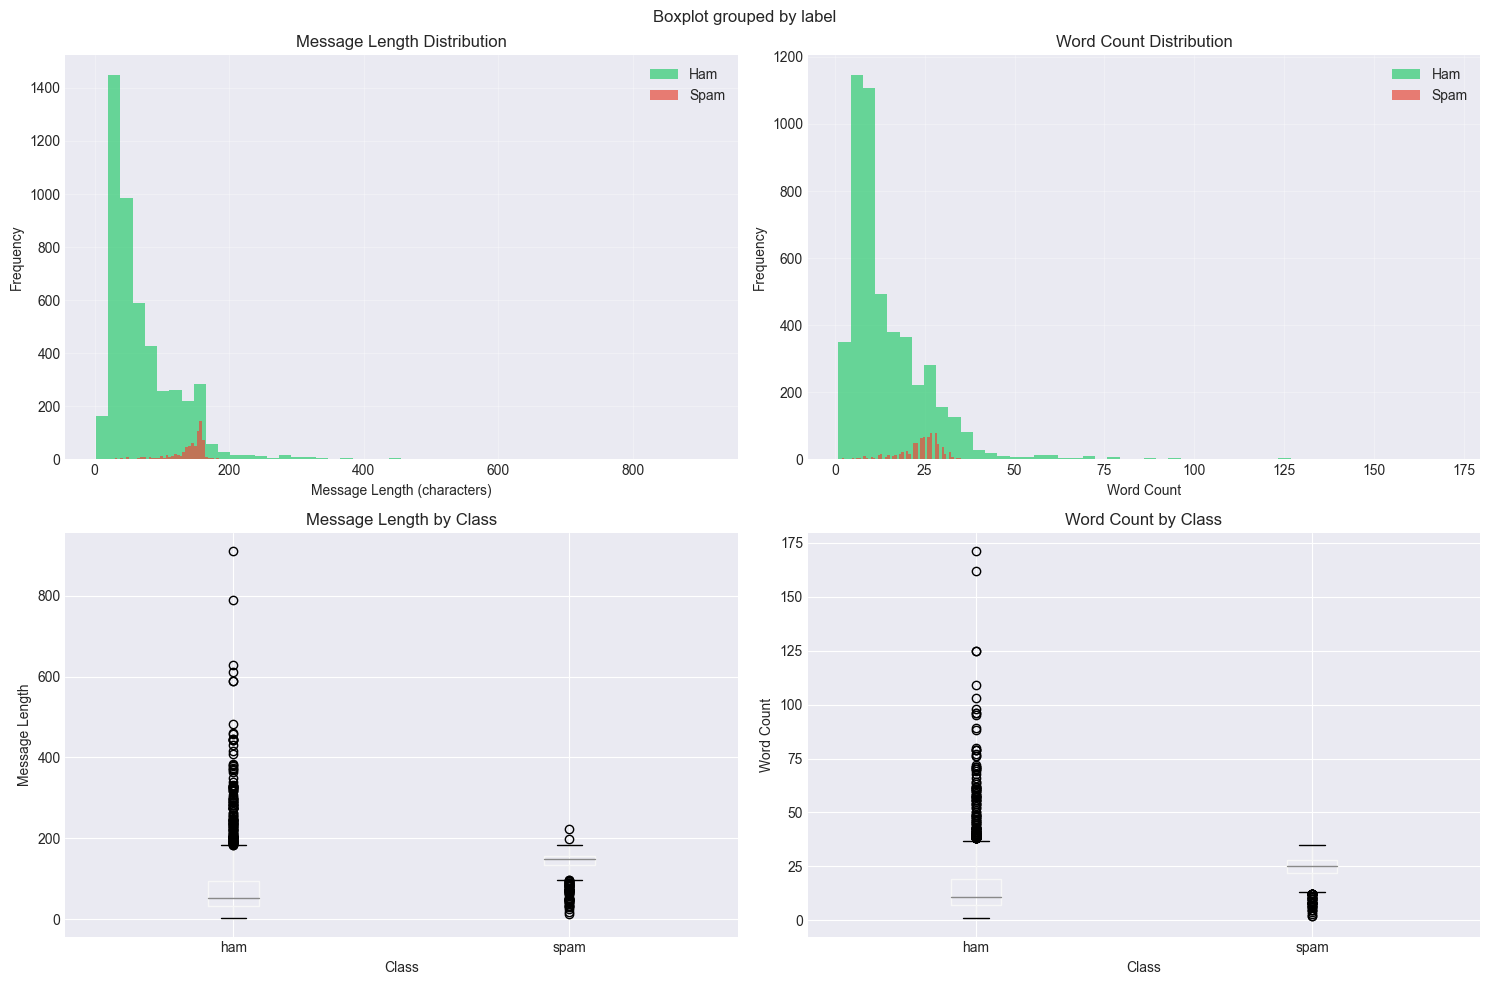


✓ Visualization saved to reports/message_length_analysis.png


In [4]:
# Calculate message lengths
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print("\n" + "="*60)
print("MESSAGE LENGTH STATISTICS")
print("="*60)

print("\nBy Character Count:")
print(df.groupby('label')['message_length'].describe())

print("\nBy Word Count:")
print(df.groupby('label')['word_count'].describe())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Character count distribution
axes[0, 0].hist(df[df['label']=='ham']['message_length'], bins=50, 
                alpha=0.7, label='Ham', color='#2ecc71')
axes[0, 0].hist(df[df['label']=='spam']['message_length'], bins=50, 
                alpha=0.7, label='Spam', color='#e74c3c')
axes[0, 0].set_xlabel('Message Length (characters)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Message Length Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Word count distribution
axes[0, 1].hist(df[df['label']=='ham']['word_count'], bins=50, 
                alpha=0.7, label='Ham', color='#2ecc71')
axes[0, 1].hist(df[df['label']=='spam']['word_count'], bins=50, 
                alpha=0.7, label='Spam', color='#e74c3c')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Word Count Distribution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plots
df.boxplot(column='message_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Message Length by Class')
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('Message Length')

df.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Class')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'message_length_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to reports/message_length_analysis.png")

In [5]:
print("\n" + "="*60)
print("SAMPLE MESSAGES")
print("="*60)

print("\n📧 HAM (Legitimate) Messages:")
print("-" * 60)
for i, msg in enumerate(df[df['label']=='ham']['message'].head(5), 1):
    print(f"{i}. {msg}\n")

print("\n⚠️  SPAM (Phishing) Messages:")
print("-" * 60)
for i, msg in enumerate(df[df['label']=='spam']['message'].head(5), 1):
    print(f"{i}. {msg}\n")


SAMPLE MESSAGES

📧 HAM (Legitimate) Messages:
------------------------------------------------------------
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my brother is not like to speak with me. They treat me like aids patent.


⚠️  SPAM (Phishing) Messages:
------------------------------------------------------------
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL3


KEYWORD FREQUENCY ANALYSIS

Urgency Keywords:
        count      mean       std  min  25%  50%  75%  max
label                                                     
ham    4825.0  0.150259  0.364825  0.0  0.0  0.0  0.0  2.0
spam    747.0  0.471218  0.608399  0.0  0.0  0.0  1.0  2.0

Financial Keywords:
        count      mean       std  min  25%  50%  75%  max
label                                                     
ham    4825.0  0.062798  0.270116  0.0  0.0  0.0  0.0  4.0
spam    747.0  0.402945  0.698249  0.0  0.0  0.0  1.0  3.0

Action Keywords:
        count      mean       std  min  25%  50%  75%  max
label                                                     
ham    4825.0  0.076891  0.274871  0.0  0.0  0.0  0.0  2.0
spam    747.0  0.823293  0.773796  0.0  0.0  1.0  1.0  3.0


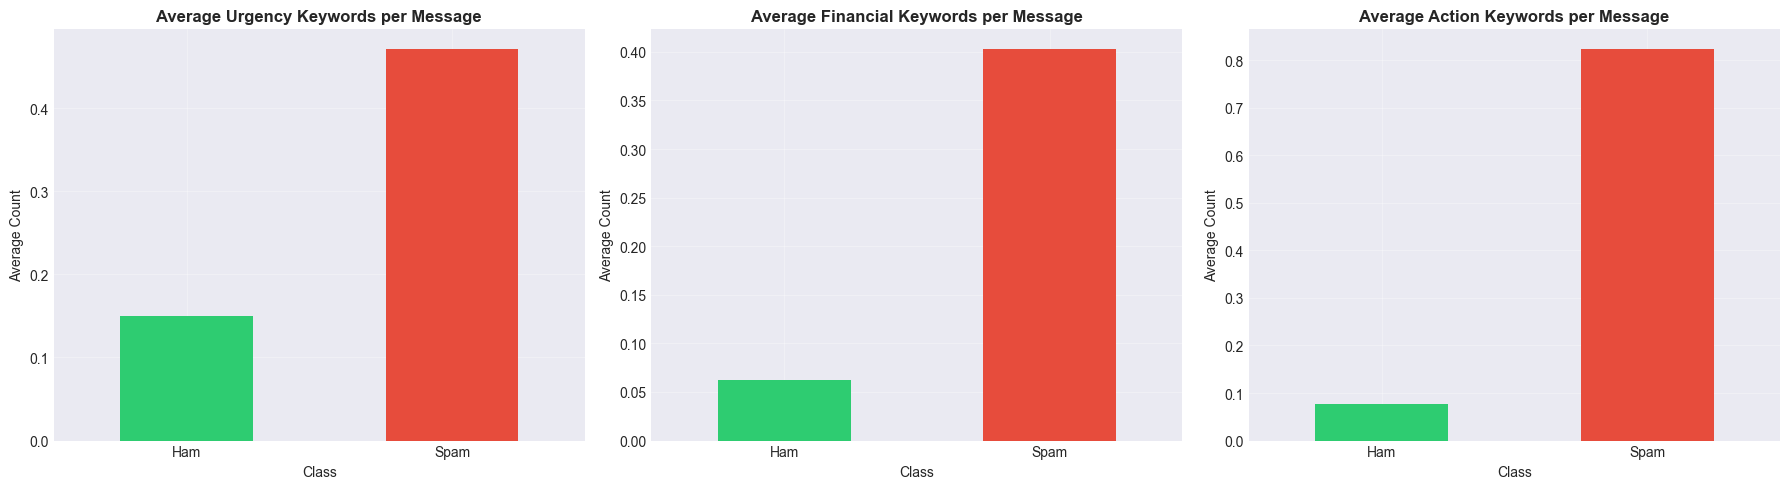


✓ Visualization saved to reports/keyword_analysis.png


In [6]:
from src.config import URGENCY_KEYWORDS, FINANCIAL_KEYWORDS, ACTION_KEYWORDS

def count_keywords(text, keywords):
    """Count how many keywords appear in text"""
    text_lower = text.lower()
    return sum(1 for keyword in keywords if keyword in text_lower)

# Add keyword counts
df['urgency_keywords'] = df['message'].apply(lambda x: count_keywords(x, URGENCY_KEYWORDS))
df['financial_keywords'] = df['message'].apply(lambda x: count_keywords(x, FINANCIAL_KEYWORDS))
df['action_keywords'] = df['message'].apply(lambda x: count_keywords(x, ACTION_KEYWORDS))

print("\n" + "="*60)
print("KEYWORD FREQUENCY ANALYSIS")
print("="*60)

print("\nUrgency Keywords:")
print(df.groupby('label')['urgency_keywords'].describe())

print("\nFinancial Keywords:")
print(df.groupby('label')['financial_keywords'].describe())

print("\nAction Keywords:")
print(df.groupby('label')['action_keywords'].describe())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

keyword_types = ['urgency_keywords', 'financial_keywords', 'action_keywords']
titles = ['Urgency Keywords', 'Financial Keywords', 'Action Keywords']
colors_map = {'ham': '#2ecc71', 'spam': '#e74c3c'}

for idx, (kw_type, title) in enumerate(zip(keyword_types, titles)):
    data = df.groupby('label')[kw_type].mean()
    data.plot(kind='bar', ax=axes[idx], color=[colors_map[x] for x in data.index])
    axes[idx].set_title(f'Average {title} per Message', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel('Average Count')
    axes[idx].set_xticklabels(['Ham', 'Spam'], rotation=0)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'keyword_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to reports/keyword_analysis.png")